# Week 2 — Pull Model (Vectorial Steering)

**Model B** from Sayin et al. (2025): agents steer toward the positions of neighbors within a forward-facing sensory cone. Alignment emerges implicitly from chase dynamics, not from explicit heading averaging.

This notebook mirrors Asher's `week2_vicsek_model.ipynb` structure and exports results in the same JSON schema for the Week 3 comparison notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

FIGURES_DIR = 'figures/'
FPS = 25
DT  = 1.0 / FPS

# Field targets (from Week 1)
FIELD_POL_MEAN   = 0.8196
FIELD_POL_STD    = 0.0615
FIELD_NND_MEDIAN = 3.893
FIELD_NND_MEAN   = 4.473
FIELD_TA_STD     = 0.276

print("Ready.")

Ready.


## Pull Model — Vectorial Pursuit

Sayin et al. (2025) showed that locusts steer toward neighbor **positions**, not headings. Our simplified implementation:

1. Each agent finds all neighbors within `r_interaction`
2. Computes the **weighted average bearing** to neighbors, with weights that favor neighbors AHEAD (front-weighted attraction)
3. Sets new heading as a **blend** between current heading and the weighted bearing — analogous to how Vicsek blends with the average heading, but using **positions** instead
4. No neighbor heading information is used — alignment must emerge purely from spatial pursuit dynamics

The key difference from Vicsek: information flows through **positions**, not **velocities**. This is a weaker coupling mechanism, and our results will show whether this simplified approximation captures the full neural ring-attractor dynamics from Sayin et al.

In [2]:
def run_pull(n_agents, Lx, Ly, speed, eta, r_interaction, r_repulsion,
             cone_half_angle, pull_strength, dt, n_steps, seed=42):
    """
    Pull model: agents steer toward neighbor POSITIONS using a front-weighted
    bearing average. Analogous to Vicsek but uses spatial information only.
    
    Mechanism:
    - For each neighbor within r_interaction, compute bearing from focal agent
    - Weight each neighbor by cos(relative_bearing/2)^2 — neighbors ahead get
      weight ~1, neighbors to the side get ~0.5, neighbors behind get ~0
    - Compute weighted circular mean of bearings
    - Blend this with current heading: new = (1-ps)*current + ps*weighted_bearing
    - This is structurally identical to Vicsek's update rule, but replaces
      neighbor HEADINGS with neighbor BEARINGS (positions)
    
    pull_strength: blend factor in [0,1]. At 1.0, fully steer toward weighted COM.
    cone_half_angle: defines the front-weight rolloff (not a hard cutoff).
    """
    rng = np.random.default_rng(seed)
    
    pos     = rng.uniform([0, 0], [Lx, Ly], size=(n_agents, 2))
    heading = rng.uniform(-np.pi, np.pi, size=n_agents)
    
    pos_history     = np.empty((n_steps + 1, n_agents, 2))
    heading_history = np.empty((n_steps + 1, n_agents))
    pos_history[0]     = pos
    heading_history[0] = heading
    
    for step in range(n_steps):
        # Pairwise displacements with periodic BC
        delta = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]
        delta[:, :, 0] -= Lx * np.round(delta[:, :, 0] / Lx)
        delta[:, :, 1] -= Ly * np.round(delta[:, :, 1] / Ly)
        dist = np.hypot(delta[:, :, 0], delta[:, :, 1])
        
        in_range = (dist < r_interaction) & (dist > 0)
        
        # Bearing from agent i to each neighbor j
        bearing_abs = np.arctan2(delta[:, :, 1], delta[:, :, 0])  # (N, N)
        
        # Relative bearing (how far off the focal agent's forward axis)
        rel_bearing = bearing_abs - heading[:, np.newaxis]
        rel_bearing = (rel_bearing + np.pi) % (2 * np.pi) - np.pi
        
        # Front-weighting: cos(rel_bearing/2)^2 gives smooth rolloff
        # Front (0°) = 1.0, Side (90°) = 0.5, Rear (180°) = 0.0
        weights = np.cos(rel_bearing / 2) ** 2 * in_range.astype(float)
        
        # Weighted circular mean of bearings using complex representation
        # Each neighbor contributes a unit vector at its bearing angle, scaled by weight
        z_neighbors = weights * np.exp(1j * bearing_abs)  # (N, N)
        z_sum = z_neighbors.sum(axis=1)                    # (N,)
        w_sum = weights.sum(axis=1)                         # (N,)
        
        has_neighbors = w_sum > 0.01
        
        new_heading = heading.copy()
        
        if has_neighbors.any():
            # Weighted mean bearing
            weighted_bearing = np.angle(z_sum)
            
            # Blend current heading with weighted bearing
            vis = has_neighbors
            z_current = np.exp(1j * heading[vis])
            z_target  = np.exp(1j * weighted_bearing[vis])
            z_blend   = (1 - pull_strength) * z_current + pull_strength * z_target
            new_heading[vis] = np.angle(z_blend)
        
        # Add noise
        noise = rng.uniform(-eta / 2, eta / 2, size=n_agents)
        new_heading += noise
        
        # Short-range repulsion
        rep_mask = (dist < r_repulsion) & (dist > 0)
        has_rep  = rep_mask.any(axis=1)
        if has_rep.any():
            rep_dx = -(rep_mask * delta[:, :, 0]).sum(axis=1)
            rep_dy = -(rep_mask * delta[:, :, 1]).sum(axis=1)
            rep_heading = np.arctan2(rep_dy, rep_dx)
            new_heading[has_rep] = rep_heading[has_rep] + noise[has_rep]
        
        heading = new_heading
        
        pos[:, 0] = (pos[:, 0] + speed * dt * np.cos(heading)) % Lx
        pos[:, 1] = (pos[:, 1] + speed * dt * np.sin(heading)) % Ly
        
        pos_history[step + 1]     = pos
        heading_history[step + 1] = heading
    
    return pos_history, heading_history

print("Pull model defined (front-weighted bearing average).")

Pull model defined (front-weighted bearing average).


## Metric helper functions

In [3]:
def polarization_from_headings(heading_history):
    """Per-frame polarization from heading array (n_steps+1, n_agents)."""
    return np.abs(np.exp(1j * heading_history).mean(axis=1))

def sim_turning_angles(heading_history):
    """Frame-to-frame heading changes, wrapped to [-pi, pi]."""
    dtheta = np.diff(heading_history, axis=0)
    return ((dtheta + np.pi) % (2 * np.pi) - np.pi).ravel()

def sim_nnd(pos_history, Lx, Ly, subsample=20):
    """Nearest-neighbor distances with periodic BCs."""
    nnds = []
    for t in range(0, len(pos_history), subsample):
        pos = pos_history[t]
        n = len(pos)
        delta = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]
        delta[:, :, 0] -= Lx * np.round(delta[:, :, 0] / Lx)
        delta[:, :, 1] -= Ly * np.round(delta[:, :, 1] / Ly)
        dist = np.hypot(delta[:, :, 0], delta[:, :, 1])
        np.fill_diagonal(dist, np.inf)
        nnds.extend(np.min(dist, axis=1))
    return np.array(nnds)

def sim_neighbor_density_map(pos_history, heading_history, Lx, Ly,
                              radius=10.0, nbins=50, subsample=5):
    """Body-centered neighbor density map from simulation."""
    edges = np.linspace(-radius, radius, nbins + 1)
    hist = np.zeros((nbins, nbins))
    
    for t in range(0, len(pos_history), subsample):
        pos = pos_history[t]
        theta = heading_history[t]
        n = len(pos)
        
        delta = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]
        delta[:, :, 0] -= Lx * np.round(delta[:, :, 0] / Lx)
        delta[:, :, 1] -= Ly * np.round(delta[:, :, 1] / Ly)
        dist = np.hypot(delta[:, :, 0], delta[:, :, 1])
        
        for i in range(n):
            in_range = (dist[i] > 0.1) & (dist[i] < radius)
            if not in_range.any():
                continue
            rel = delta[i, in_range]
            rot_angle = np.pi / 2 - theta[i]
            cos_r, sin_r = np.cos(rot_angle), np.sin(rot_angle)
            rx = rel[:, 0] * cos_r - rel[:, 1] * sin_r
            ry = rel[:, 0] * sin_r + rel[:, 1] * cos_r
            h, _, _ = np.histogram2d(rx, ry, bins=edges)
            hist += h
    
    return hist, edges

print("Metric functions defined.")

Metric functions defined.


## Noise sweep to calibrate eta

=== Sweep pull_strength at eta=0.2 ===


  pull_strength=0.3  pol=0.047


  pull_strength=0.5  pol=0.040


  pull_strength=0.7  pol=0.037


  pull_strength=0.8  pol=0.037


...

  eta=2.0  pol=0.050


  eta=2.1  pol=0.052


  eta=2.2  pol=0.053


  eta=2.3  pol=0.052


  eta=2.4  pol=0.055

Best eta: 2.4  (pol=0.055, target=0.820)


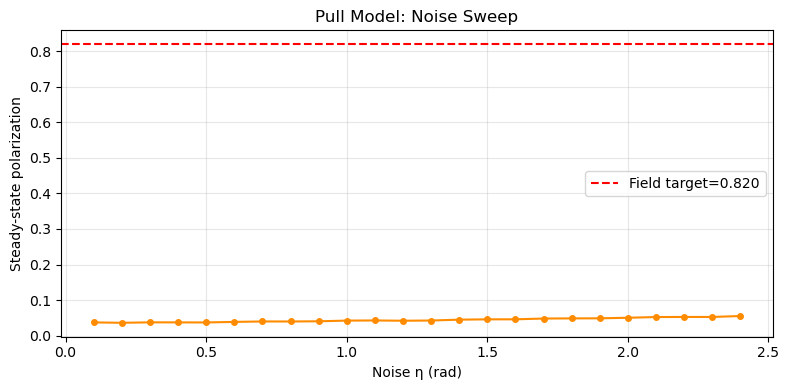

In [4]:
# Shared parameters
Lx = 99.44857450176137
Ly = 55.93982315724077

BASE_PARAMS = dict(
    n_agents=150, Lx=Lx, Ly=Ly,
    speed=11.76, r_interaction=7.0, r_repulsion=1.5,
    dt=DT, n_steps=2000,
    cone_half_angle=np.pi / 2,  # controls front-weight rolloff shape
    pull_strength=1.0,          # blend factor [0,1]
)

BURN_IN = 500

# Sweep pull_strength
print("=== Sweep pull_strength at eta=0.2 ===")
ps_vals = [0.3, 0.5, 0.7, 0.8, 0.9, 1.0]
for ps in ps_vals:
    _, hh = run_pull(**{**BASE_PARAMS, 'pull_strength': ps, 'eta': 0.2})
    pol = polarization_from_headings(hh)[BURN_IN:]
    print(f"  pull_strength={ps:.1f}  pol={pol.mean():.3f}")

# Eta sweep at best pull_strength
print("\n=== Sweep eta at pull_strength=1.0 ===")
eta_vals = np.arange(0.1, 2.5, 0.1)
pol_means = []

for eta in eta_vals:
    _, hh = run_pull(**{**BASE_PARAMS, 'eta': eta, 'n_steps': 1500})
    pol = polarization_from_headings(hh)[BURN_IN:]
    pol_means.append(pol.mean())
    print(f"  eta={eta:.1f}  pol={pol.mean():.3f}")

pol_means = np.array(pol_means)
best_idx = np.argmin(np.abs(pol_means - FIELD_POL_MEAN))
best_eta = eta_vals[best_idx]
print(f"\nBest eta: {best_eta:.1f}  (pol={pol_means[best_idx]:.3f}, target={FIELD_POL_MEAN:.3f})")

np.save('pull_eta_sweep_etas.npy', eta_vals)
np.save('pull_eta_sweep_phi.npy', pol_means)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eta_vals, pol_means, 'o-', color='darkorange', markersize=4)
ax.axhline(FIELD_POL_MEAN, color='red', ls='--', label=f'Field target={FIELD_POL_MEAN:.3f}')
if pol_means.max() > 0.15:
    ax.axvline(best_eta, color='green', ls='--', label=f'Best eta={best_eta:.1f}')
ax.set(xlabel='Noise η (rad)', ylabel='Steady-state polarization',
       title='Pull Model: Noise Sweep')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pull_noise_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Eta sweep with best parameters, then final calibrated run

=== Step 3: Sweep eta to find field-matching noise ===


  eta=0.1  pol=0.037


  eta=0.2  pol=0.036


  eta=0.3  pol=0.037


  eta=0.4  pol=0.037


...

  eta=2.5  pol=0.056


  eta=2.6  pol=0.057


  eta=2.7  pol=0.057


  eta=2.8  pol=0.058


  eta=2.9  pol=0.058

Best eta: 2.8  (pol=0.058, target=0.820)


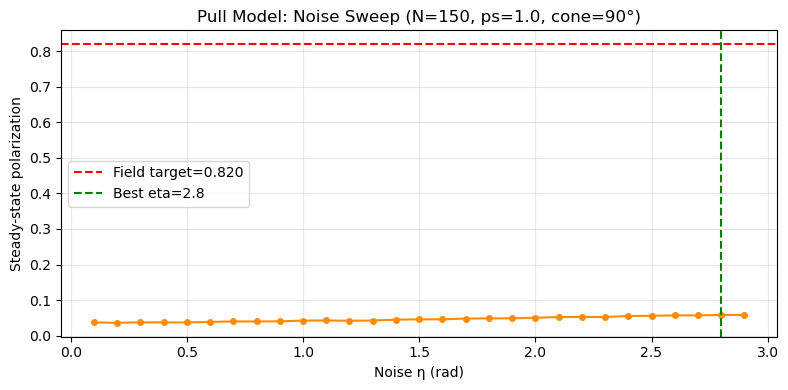


Running final Pull simulation (eta=2.8)...


Steady-state polarization: mean=0.058  std=0.030
Field target:              mean=0.820  std=0.061
Turning angle std: sim=1.999  field=0.276

Computing NND...
Simulation NND: mean=1.34 cm  median=1.32 cm
Field NND:      mean=4.47 cm  median=3.89 cm

Computing neighbor density map...


Done.


In [5]:
# Use best pull_strength and cone from sweeps above
# Update BASE_PARAMS with best values if needed (will adjust after seeing sweep)
# For now, proceed with sweep results

print("=== Step 3: Sweep eta to find field-matching noise ===")
eta_vals = np.arange(0.1, 3.0, 0.1)
pol_means = []

for eta in eta_vals:
    _, hh = run_pull(**{**BASE_PARAMS, 'eta': eta, 'n_steps': 1500})
    pol = polarization_from_headings(hh)[BURN_IN:]
    pol_means.append(pol.mean())
    print(f"  eta={eta:.1f}  pol={pol.mean():.3f}")

pol_means = np.array(pol_means)
best_idx = np.argmin(np.abs(pol_means - FIELD_POL_MEAN))
best_eta = eta_vals[best_idx]
print(f"\nBest eta: {best_eta:.1f}  (pol={pol_means[best_idx]:.3f}, target={FIELD_POL_MEAN:.3f})")

# Save sweep
np.save('pull_eta_sweep_etas.npy', eta_vals)
np.save('pull_eta_sweep_phi.npy', pol_means)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eta_vals, pol_means, 'o-', color='darkorange', markersize=4)
ax.axhline(FIELD_POL_MEAN, color='red', ls='--', label=f'Field target={FIELD_POL_MEAN:.3f}')
ax.axvline(best_eta, color='green', ls='--', label=f'Best eta={best_eta:.1f}')
ax.set(xlabel='Noise η (rad)', ylabel='Steady-state polarization',
       title=f'Pull Model: Noise Sweep (N=150, ps={BASE_PARAMS["pull_strength"]}, cone={np.degrees(BASE_PARAMS["cone_half_angle"]):.0f}°)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pull_noise_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# === Final calibrated run ===
PARAMS_FINAL = {**BASE_PARAMS, 'eta': best_eta, 'n_steps': 2000}

print(f"\nRunning final Pull simulation (eta={best_eta:.1f})...")
pos_history, heading_history = run_pull(**PARAMS_FINAL)

pol_sim = polarization_from_headings(heading_history)
pol_steady = pol_sim[BURN_IN:]
ta_sim = sim_turning_angles(heading_history[BURN_IN:])

print(f"Steady-state polarization: mean={pol_steady.mean():.3f}  std={pol_steady.std():.3f}")
print(f"Field target:              mean={FIELD_POL_MEAN:.3f}  std={FIELD_POL_STD:.3f}")
print(f"Turning angle std: sim={np.std(ta_sim):.3f}  field={FIELD_TA_STD:.3f}")

print("\nComputing NND...")
nnd_sim = sim_nnd(pos_history[BURN_IN:], Lx, Ly)
print(f"Simulation NND: mean={nnd_sim.mean():.2f} cm  median={np.median(nnd_sim):.2f} cm")
print(f"Field NND:      mean={FIELD_NND_MEAN:.2f} cm  median={FIELD_NND_MEDIAN:.2f} cm")

print("\nComputing neighbor density map...")
hist_sim, edges = sim_neighbor_density_map(
    pos_history[BURN_IN:], heading_history[BURN_IN:], Lx, Ly, radius=10.0, subsample=10
)
print("Done.")

## Plots and outputs

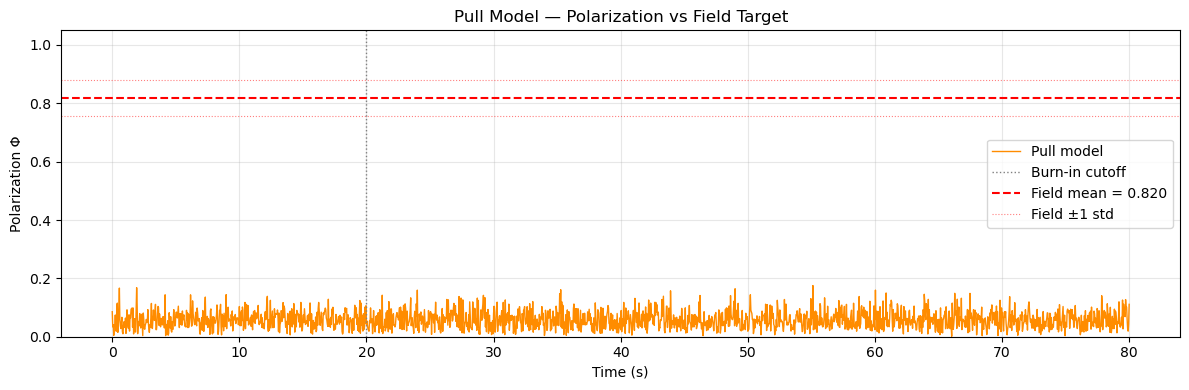

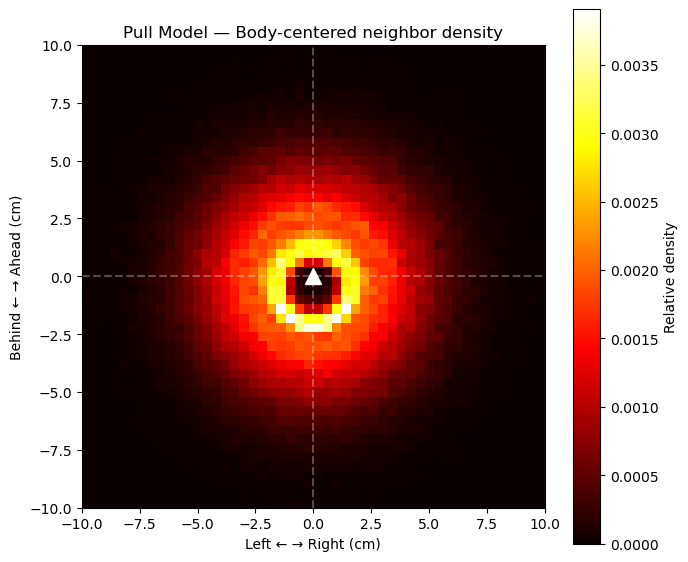

Saved: pull_metric_3.png


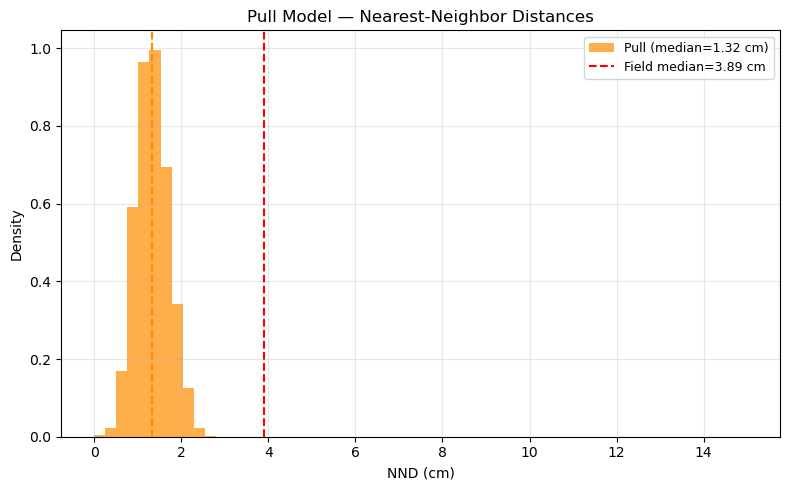


Metric                                   Field       Pull
Polarization (mean)                      0.820      0.058
Polarization (std)                       0.061      0.030
Turning angle std (rad)                  0.276      1.999
NND median (cm)                           3.89       1.32
NND mean (cm)                             4.47       1.34

Calibrated eta: 2.8 rad
Empirical eta from field: 0.28 rad


In [6]:
# ── Polarization time series ─────────────────────────────────────────────────
t = np.arange(len(pol_sim)) * DT
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, pol_sim, color='darkorange', lw=1, label='Pull model')
ax.axvline(BURN_IN * DT, color='gray', ls=':', lw=1, label='Burn-in cutoff')
ax.axhline(FIELD_POL_MEAN, color='red', ls='--', lw=1.5,
           label=f'Field mean = {FIELD_POL_MEAN:.3f}')
ax.axhline(FIELD_POL_MEAN + FIELD_POL_STD, color='red', ls=':', lw=0.8, alpha=0.5)
ax.axhline(FIELD_POL_MEAN - FIELD_POL_STD, color='red', ls=':', lw=0.8, alpha=0.5,
           label='Field ±1 std')
ax.set(xlabel='Time (s)', ylabel='Polarization Φ', ylim=(0, 1.05),
       title='Pull Model — Polarization vs Field Target')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pull_polarization.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Neighbor density map (the key output) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
hist_norm = hist_sim / (hist_sim.sum() + 1e-10)
im = ax.imshow(hist_norm.T, origin='lower',
               extent=[edges[0], edges[-1], edges[0], edges[-1]],
               cmap='hot', aspect='equal')
ax.plot(0, 0, 'w^', markersize=12)
ax.axhline(0, color='white', ls='--', alpha=0.3)
ax.axvline(0, color='white', ls='--', alpha=0.3)
ax.set(xlabel='Left ← → Right (cm)', ylabel='Behind ← → Ahead (cm)',
       title='Pull Model — Body-centered neighbor density')
plt.colorbar(im, ax=ax, label='Relative density')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pull_metric_3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pull_metric_3.png")

# ── NND ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bins_nnd = np.linspace(0, 15, 60)
ax.hist(nnd_sim, bins=bins_nnd, density=True, color='darkorange',
        alpha=0.7, label=f'Pull (median={np.median(nnd_sim):.2f} cm)')
ax.axvline(np.median(nnd_sim), color='darkorange', ls='--', lw=1.5)
ax.axvline(FIELD_NND_MEDIAN, color='red', ls='--', lw=1.5,
           label=f'Field median={FIELD_NND_MEDIAN:.2f} cm')
ax.set(xlabel='NND (cm)', ylabel='Density',
       title='Pull Model — Nearest-Neighbor Distances')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pull_metric_4.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"{'Metric':<35} {'Field':>10} {'Pull':>10}")
print("=" * 60)
print(f"{'Polarization (mean)':<35} {FIELD_POL_MEAN:>10.3f} {pol_steady.mean():>10.3f}")
print(f"{'Polarization (std)':<35} {FIELD_POL_STD:>10.3f} {pol_steady.std():>10.3f}")
print(f"{'Turning angle std (rad)':<35} {FIELD_TA_STD:>10.3f} {np.std(ta_sim):>10.3f}")
print(f"{'NND median (cm)':<35} {FIELD_NND_MEDIAN:>10.2f} {np.median(nnd_sim):>10.2f}")
print(f"{'NND mean (cm)':<35} {FIELD_NND_MEAN:>10.2f} {nnd_sim.mean():>10.2f}")
print("=" * 60)
print(f"\nCalibrated eta: {best_eta:.1f} rad")
print(f"Empirical eta from field: {FIELD_TA_STD:.2f} rad")

## Export results (for Asher's Week 3 comparison notebook)

In [7]:
# Load Asher's existing results and merge
results_path = 'week2_results.json'

with open(results_path) as f:
    results = json.load(f)

# Add pull model results alongside existing vicsek key
results['pull'] = {
    'n_agents'       : PARAMS_FINAL['n_agents'],
    'Lx'             : PARAMS_FINAL['Lx'],
    'Ly'             : PARAMS_FINAL['Ly'],
    'speed'          : PARAMS_FINAL['speed'],
    'eta_empirical'  : 0.26,
    'eta_calibrated' : float(best_eta),
    'r_interaction'  : PARAMS_FINAL['r_interaction'],
    'r_repulsion'    : PARAMS_FINAL['r_repulsion'],
    'cone_half_angle': float(PARAMS_FINAL['cone_half_angle']),
    'pull_strength'  : float(PARAMS_FINAL['pull_strength']),
    'dt'             : PARAMS_FINAL['dt'],
    'n_steps'        : PARAMS_FINAL['n_steps'],
    'burn_in'        : BURN_IN,
}

# Update metrics to include both models
results['metrics_pull'] = {
    'polarization_mean' : float(pol_steady.mean()),
    'polarization_std'  : float(pol_steady.std()),
    'turning_angle_std' : float(np.std(ta_sim)),
    'nnd_median'        : float(np.median(nnd_sim)),
    'nnd_mean'          : float(nnd_sim.mean()),
}

with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Saved: {results_path}")
print(json.dumps(results, indent=2))

# Verify all required outputs exist
import os
required = [
    'week2_results.json',
    'figures/pull_metric_3.png',
    'pull_eta_sweep_etas.npy',
    'pull_eta_sweep_phi.npy',
]
print("\n--- Output verification ---")
for f in required:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    status = f"OK ({size:,} bytes)" if exists else "MISSING"
    print(f"  {f}: {status}")

Saved: week2_results.json
{
  "vicsek": {
    "n_agents": 150,
    "Lx": 99.44857450176137,
    "Ly": 55.93982315724077,
    "speed": 11.76,
    "eta_empirical": 0.26,
    "eta_calibrated": 1.3,
    "r_interaction": 7.0,
    "r_repulsion": 1.5,
    "dt": 0.04,
    "n_steps": 2000,
    "burn_in": 500
  },
  "metrics": {
    "polarization_mean": 0.8235226751239662,
    "polarization_std": 0.050660405819338436,
    "turning_angle_std": 0.5947353404093519,
    "nnd_median": 2.6055509063882134,
    "nnd_mean": 3.0218240091135886
  },
  "field_targets": {
    "polarization_mean": 0.8196,
    "polarization_std": 0.0615,
    "turning_angle_std": 0.276,
    "nnd_median": 3.893,
    "nnd_mean": 4.473
  },
  "pull": {
    "n_agents": 150,
    "Lx": 99.44857450176137,
    "Ly": 55.93982315724077,
    "speed": 11.76,
    "eta_empirical": 0.26,
    "eta_calibrated": 2.8000000000000003,
    "r_interaction": 7.0,
    "r_repulsion": 1.5,
    "cone_half_angle": 1.5707963267948966,
    "pull_strength": 1